<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/0508_%EC%84%B8%EC%85%98_RNN_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 넷플릭스 주가 예측하기 RNN 코드 실습

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data_path='/content/drive/MyDrive/Colab/ESAA/netflix_train.csv'

## 1. 데이터 가져오기

In [3]:
# 데이터 가져오기
import pandas as pd
data = pd.read_csv(data_path)
data.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


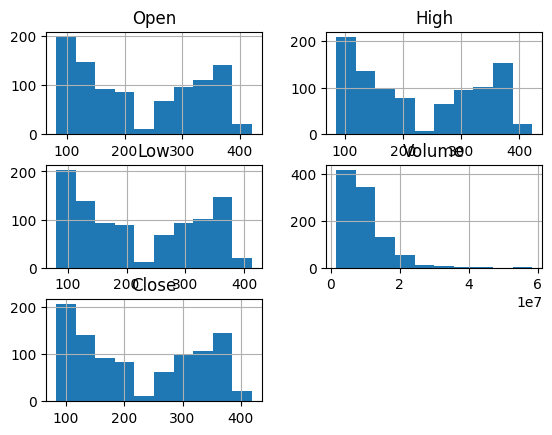

In [5]:
# 데이터 분포를 히스토그램으로 살펴보기
import matplotlib.pyplot as plt

# 개장가, 최고가, 최저가 추가
# 종가 추가
hist = data.hist()
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [6]:
import numpy as np
from torch.utils.data.dataset import Dataset
from sklearn.preprocessing import MinMaxScaler
import torch
import pandas as pd

class Netflix(Dataset):  # 클래스 선언
    def __init__(self):
        # 데이터 읽기
        df = pd.read_csv(data_path)
        self.data = df[['Open', 'High', 'Low', 'Volume']].values # 종가를 제외한 입력 데이터
        self.close_prices = df['Close'].values # 종가 데이터 (레이블)

        # 입력 데이터 정규화
        self.scaler_data = MinMaxScaler()
        self.normalized_data = self.scaler_data.fit_transform(self.data)

        # 종가 데이터 정규화
        self.scaler_close = MinMaxScaler()
        # reshape(-1, 1) to make it 2D for MinMaxScaler
        self.normalized_close = self.scaler_close.fit_transform(self.close_prices.reshape(-1, 1))

    def __len__(self):
        return len(self.data) - 30 # 사용 가능한 배치 개수 (30일치 시퀀스 학습 후 마지막 날 예측)

    def __getitem__(self, i):
        # 입력 데이터 30일치 읽기
        data_sequence = torch.FloatTensor(self.normalized_data[i : i + 30])
        # 종가 데이터 (30일 시퀀스의 마지막 날 종가를 예측)
        label = torch.FloatTensor(self.normalized_close[i + 29])

        return data_sequence, label

## 3. RNN 모델 정의

In [7]:
# RNN 클래스 정의

import torch
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

        # RNN층의 정의
        # input_size는 Open, High, Low, Volume 4개 특성
        # hidden_size와 num_layers는 임의로 설정
        self.rnn = nn.RNN(input_size=4, hidden_size=32, num_layers=2, batch_first=True)

        # 주가를 예측하는 MLP층 정의
        # RNN의 hidden_size를 입력으로 받아 하나의 예측값 출력
        self.fc = nn.Linear(32, 1)

        # 활성화 함수 정의 (필요에 따라)
        self.relu = nn.ReLU()

    # RNN 모델의 순전파 정의
    def forward(self, x, h0):
        # RNN층의 출력
        # x: (batch_size, sequence_length, input_size)
        # h0: (num_layers, batch_size, hidden_size)
        out, hn = self.rnn(x, h0)

        # MLP층의 입력으로 사용되게 모양 변경
        # 마지막 시점의 출력을 사용 (out[:, -1, :])
        out = self.relu(out[:, -1, :]) # out: (batch_size, hidden_size)

        # MLP층을 이용해 종가 예측
        x = self.fc(out)

        # 예측한 종가를 1차원 벡터로 표현
        return x.squeeze(1)

## 4. 모델 학습하기

In [8]:
# 모델과 데이터셋 정의
import tqdm
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델의 정의
model = RNN().to(device)
# 데이터셋의 정의
dataset = Netflix()

In [9]:
# 데이터로더 정의
# 배치 크기를 32로 설정
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [10]:
# 최적화 정의
# 학습률은 0.0001로 설정
learning_rate = 0.0001
# 사용할 최적화 설정
optim = Adam(model.parameters(), lr=learning_rate)

# 손실 함수 정의
criterion = nn.MSELoss()

In [11]:
# 학습 루프 정의
# 에포크: 200
for epoch in range(200):
    iterator = tqdm.tqdm(loader)
    for data_batch, label_batch in iterator:
        optim.zero_grad()

        data_batch = data_batch.to(device)
        label_batch = label_batch.to(device)

        # 초기 은닉 상태 (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(2, data_batch.size(0), 32).to(device) # RNN의 num_layers와 hidden_size에 맞게 설정

        # 모델의 예측값
        prediction = model(data_batch, h0)

        # 손실의 계산
        loss = criterion(prediction, label_batch)

        # 오차 역전파
        loss.backward()
        # 최적화 진행
        optim.step()

        iterator.set_description(f"epoch:{epoch} loss:{loss.item():.4f}")

# 모델 저장
torch.save(model.state_dict(), "./rnn_model.pth")

  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch:0 loss:0.2053:  73%|███████▎  | 22/30 [00:00<00:00, 33.97it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([9, 1])) that is different to the input size (torch.Size([9])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch:199 loss:0.1432: 100%|██████████| 30/30 [00:00<00:00, 177.33it/s]


## 5. 모델 성능 평가하기

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


평가 손실: 0.0895


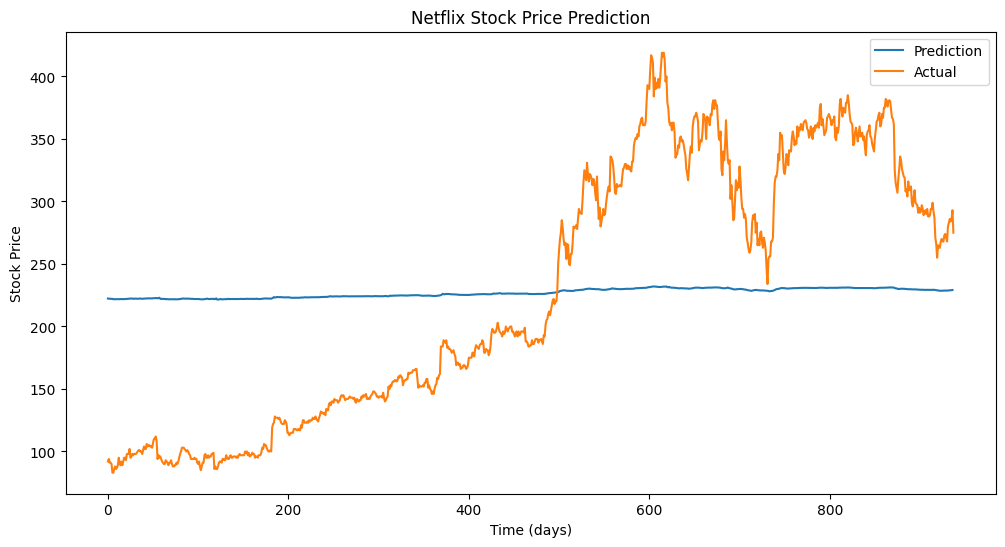

In [12]:
import matplotlib.pyplot as plt

# 모델 불러오기
model = RNN().to(device)
model.load_state_dict(torch.load("./rnn_model.pth"))
model.eval() # 모델을 평가 모드로 설정

# 예측값을 위한 데이터로더
test_loader = DataLoader(dataset, batch_size=1) # 배치 크기를 1로 설정하여 각 시퀀스별 예측 확인

# 예측값들을 저장하는 리스트
preds = []
actuals = []
total_loss = 0.0

with torch.no_grad():
    for data_batch, label_batch in test_loader:
        data_batch = data_batch.to(device)
        label_batch = label_batch.to(device)

        # 초기 은닉 상태 정의
        h0 = torch.zeros(2, data_batch.size(0), 32).to(device)

        # 모델의 예측값 출력
        prediction = model(data_batch, h0)

        # 예측값을 리스트에 추가 (inverse_transform을 위해 CPU로 이동 후 numpy 변환)
        preds.append(prediction.cpu().numpy())
        actuals.append(label_batch.cpu().numpy())

        # 손실 계산
        loss = criterion(prediction, label_batch)
        total_loss += loss.item()

# 예측값과 실제값을 원래 스케일로 되돌리기
preds = dataset.scaler_close.inverse_transform(np.array(preds).reshape(-1, 1))
actuals = dataset.scaler_close.inverse_transform(np.array(actuals).reshape(-1, 1))

# 손실의 평균치 계산
mean_loss = total_loss / len(test_loader)
print(f"평가 손실: {mean_loss:.4f}")

# 데이터셋에서 원본 종가 데이터 (look_back 기간 이후부터)
# label_batch는 이미 정규화된 것이므로, dataset.close_prices에서 가져와야 함
# dataset.close_prices는 원본 스케일이므로, normalized_close 대신 사용
# len(dataset.close_prices) - 30 (for len(dataset)) -> 30일치 시퀀스를 고려하여 실제 종가 가져오기
actual_prices_for_plot = dataset.close_prices[29:] # 29부터 시작하여 예측된 부분과 일치하도록

# 그래프 출력 (정규화 해제된 값으로)
plt.figure(figsize=(12, 6))
plt.plot(preds, label="Prediction")
plt.plot(actual_prices_for_plot, label="Actual")
plt.title("Netflix Stock Price Prediction")
plt.xlabel("Time (days)")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

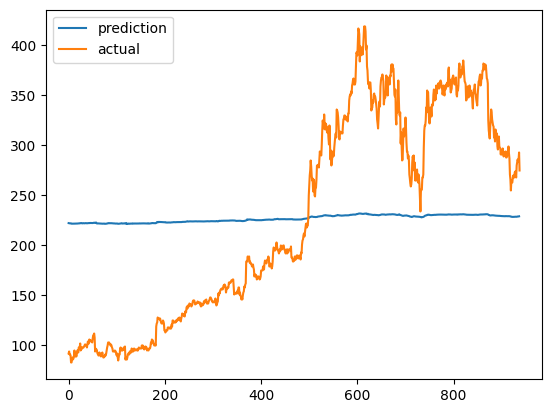

In [14]:
# 그래프 출력
plt.plot(preds, label="prediction")
plt.plot(actual_prices_for_plot, label="actual")
plt.legend()
plt.show()